# 07 — Demo: ceo pipeline na par slika

Kratka, finalna demonstracija celog toka (propozicije): učitaj model → predvidi →
prebroj → uporedi sa ground truth, na par konkretnih test slika. Koristimo
**M0 (baseline)** — najbolji model po evaluaciji u `06_evaluation_and_comparison.ipynb`
(F1=0.777 na test skupu, vs 0.737 za M1 i 0.753 za M2).

```
slika -> model -> heatmap [0,1] -> prag (0.65, biran na validaciji)
      -> čišćenje (MIN_OBJECT_SIZE, popuni rupe) -> watershed -> centroidi ćelija -> broj
```

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

from src import config
from src.data_loading import make_dataset
from src.models import build_model
from src.train import get_device
from src.postprocess import predict_mask, count_from_mask

In [2]:
device = get_device()
MODEL_NAME = "M0_baseline"

model = build_model(attention=False, activation="elu").to(device)
model.load_state_dict(torch.load(config.MODELS_DIR / f"{MODEL_NAME}.pth", map_location=device))
model.eval()
threshold = float((config.MODELS_DIR / f"{MODEL_NAME}_threshold.txt").read_text().strip())
print(f"Model: {MODEL_NAME}, threshold={threshold}, device={device}")

Model: M0_baseline, threshold=0.65, device=cpu


/home/korisnik/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
test_ds = make_dataset(split="test", form="full", augment=False, cache=False)
test_ids = [test_ds.samples[i][0] for i in range(len(test_ds))]

# tri primera: prazna/retka, srednja, gusta slika (raznovrsnost za demo)
counts = []
for i, iid in enumerate(test_ids):
    _, mask, _ = test_ds[i]
    counts.append((int(mask.sum().item() > 0) and int((np.array(Image.open(config.MASK_DIR/iid))>0).sum()), iid))
# gustina po broju foreground piksela je dovoljan proxy za izbor primera ovde
fg_counts = [(int((np.array(Image.open(config.MASK_DIR/iid)) > 0).sum()), iid) for iid in test_ids]
fg_counts.sort()
sparse_iid = fg_counts[len(fg_counts)//10][1]      # retka (donji decil)
medium_iid = fg_counts[len(fg_counts)//2][1]       # srednja (medijana)
dense_iid  = fg_counts[-1][1]                       # najgušća

demo_ids = [sparse_iid, medium_iid, dense_iid]
print("Demo slike (retka, srednja, gusta):", demo_ids)

Demo slike (retka, srednja, gusta): ['Mar22bS2C1R1_LHr_200x_y.png', 'Mar21bS1C2R3_VLPAGr_200x_y.png', 'MAR38S1C3R1_LHR_20_o.png']


In [4]:
def run_pipeline(iid):
    img = np.array(Image.open(config.IMG_DIR / iid).convert("RGB"))
    gt_mask = np.array(Image.open(config.MASK_DIR / iid)) > 0

    img_t = torch.from_numpy(img / 255.0).permute(2, 0, 1).float().unsqueeze(0)
    with torch.no_grad():
        heatmap = model(img_t.to(device)).cpu().numpy()[0, 0]

    pred_labeled, pred_centroids, n_pred = predict_mask(heatmap, threshold)
    gt_labeled, gt_centroids, n_true = count_from_mask(gt_mask)
    return img, heatmap, pred_labeled, pred_centroids, n_pred, gt_labeled, gt_centroids, n_true

results = {iid: run_pipeline(iid) for iid in demo_ids}
for iid, r in results.items():
    n_pred, n_true = r[4], r[7]
    print(f"{iid}: predviđeno={n_pred}, GT={n_true}, greška={abs(n_pred-n_true)}")

Mar22bS2C1R1_LHr_200x_y.png: predviđeno=0, GT=0, greška=0
Mar21bS1C2R3_VLPAGr_200x_y.png: predviđeno=15, GT=6, greška=9
MAR38S1C3R1_LHR_20_o.png: predviđeno=48, GT=53, greška=5


## Vizuelizacija: slika, predikcija centara ćelija, GT centri

/tmp/ipykernel_52860/1965339480.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row, 1].legend(loc="upper right")
/tmp/ipykernel_52860/1965339480.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row, 2].legend(loc="upper right")


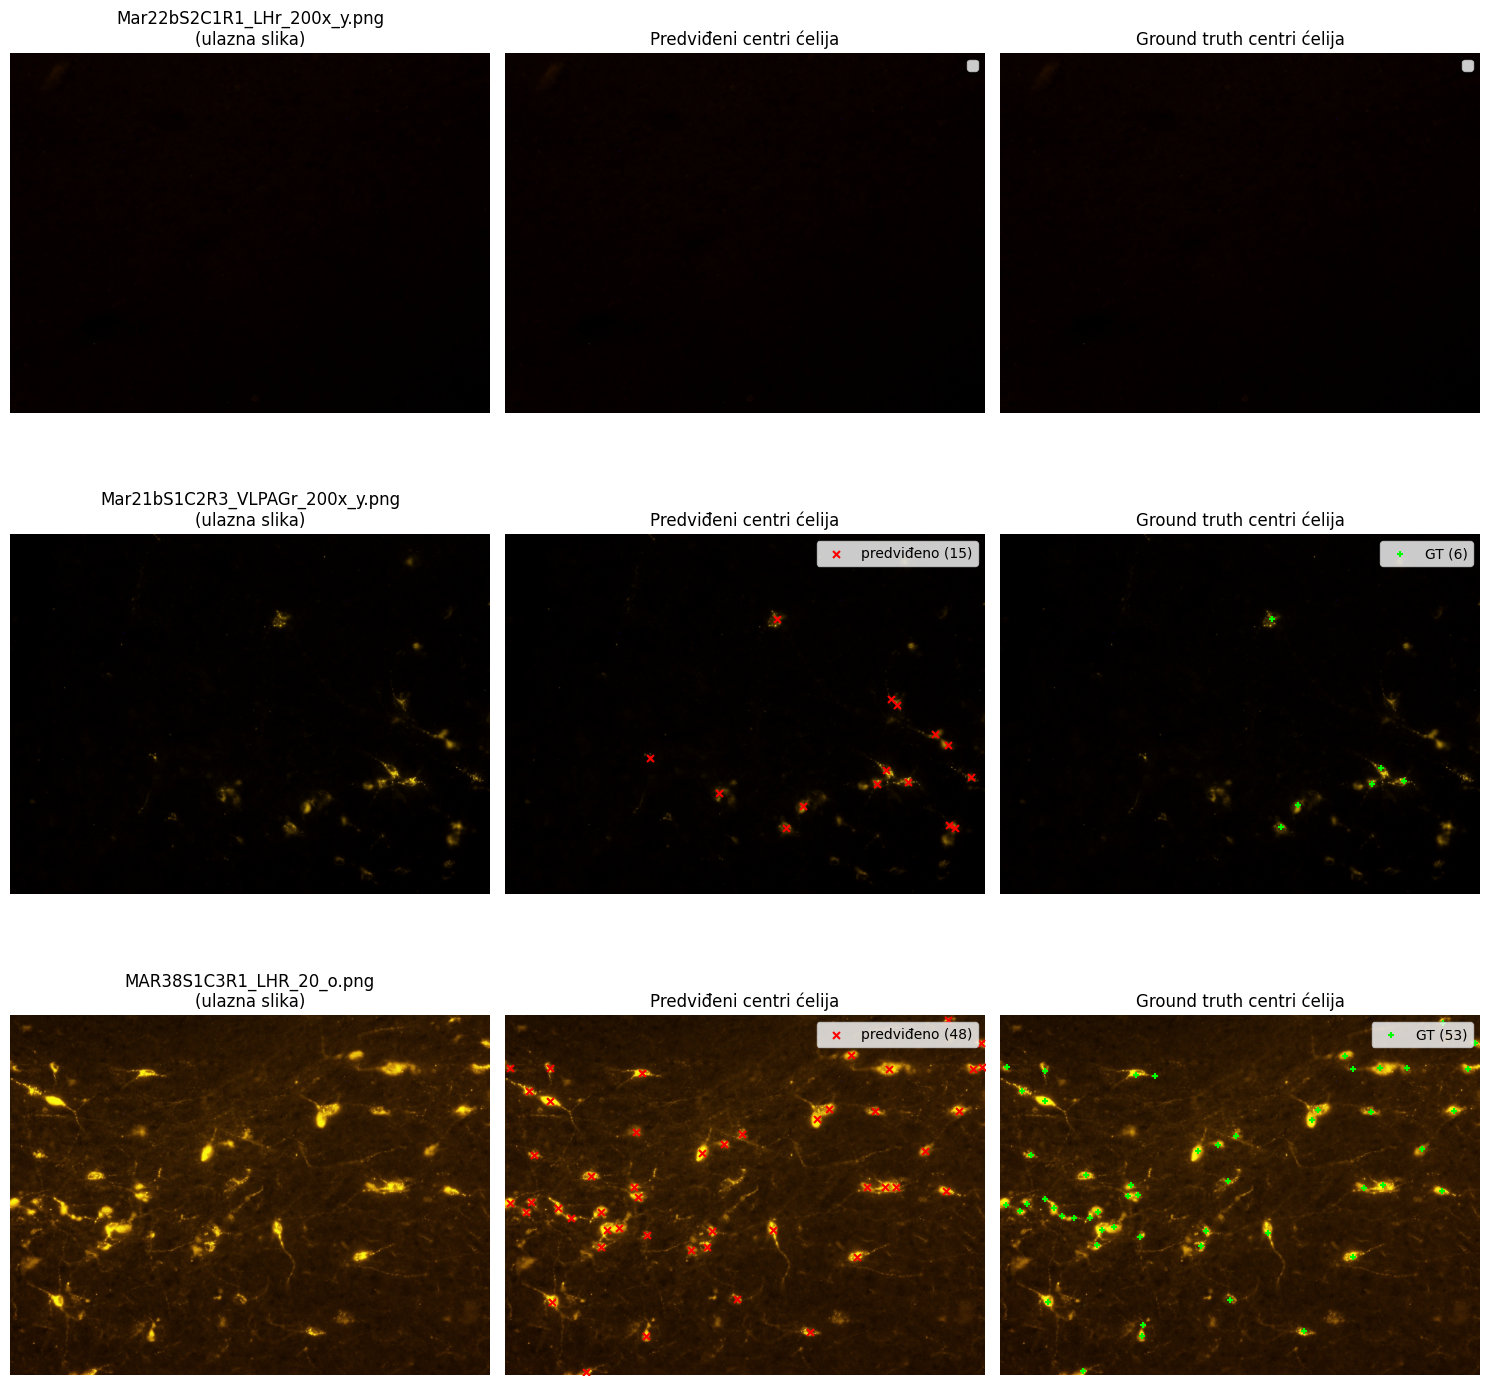

In [5]:
fig, axes = plt.subplots(len(demo_ids), 3, figsize=(15, 5 * len(demo_ids)))
for row, iid in enumerate(demo_ids):
    img, heatmap, pred_labeled, pred_centroids, n_pred, gt_labeled, gt_centroids, n_true = results[iid]

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{iid}\n(ulazna slika)")

    axes[row, 1].imshow(img)
    if pred_centroids:
        ys, xs = zip(*pred_centroids)
        axes[row, 1].scatter(xs, ys, c="red", s=25, marker="x", label=f"predviđeno ({n_pred})")
    axes[row, 1].legend(loc="upper right")
    axes[row, 1].set_title("Predviđeni centri ćelija")

    axes[row, 2].imshow(img)
    if gt_centroids:
        ys, xs = zip(*gt_centroids)
        axes[row, 2].scatter(xs, ys, c="lime", s=25, marker="+", label=f"GT ({n_true})")
    axes[row, 2].legend(loc="upper right")
    axes[row, 2].set_title("Ground truth centri ćelija")

for a in axes.ravel():
    a.axis("off")
plt.tight_layout()
plt.show()

## Rezime

Model M0 (baseline c-ResUnet) tačno prati ceo pipeline: fluorescentna slika →
heatmap verovatnoća → binarizacija (prag biran na validaciji) → čišćenje šuma →
watershed razdvajanje dodirnutih ćelija → broj i lokacije ćelija.

Na tri primera različite gustine (retka/srednja/gusta test slika) vidi se
tipično ponašanje modela: dobro prati GT na retkim i srednje gustim slikama,
greška raste na najgušćoj slici (očekivano — i po [1] i po [Tema], zbijene
slike su najteže za sve modele u ovom projektu, vidi kvalitativnu analizu u
`06_evaluation_and_comparison.ipynb`).

Pune, agregirane metrike na celom test skupu (70 slika) i poređenje sva tri
modela (M0/M1/M2) nalaze se u `06_evaluation_and_comparison.ipynb`.